# Fine-tune Gemma3n on videos

In this notebook, we will see how to fine-tune Gemma3n with video dataset, with WandB logging and HuggingFace upload.

## Install Dependencies

In [81]:
import locale
def get_preferred_encoding(do_setlocale=True):
    return "UTF-8"
locale.getpreferredencoding = get_preferred_encoding

import os
os.environ["PYTHONIOENCODING"] = "utf-8"
os.environ["LANG"] = "en_US.UTF-8"

In [1]:
!pip install -U -q timm transformers trl peft datasets


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
!pip install opencv-python



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [3]:
!pip install tensorboard



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [4]:
!pip install wandb --upgrade
!pip install --upgrade typing_extensions pydantic pydantic-core


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


## WandB Setup

In [96]:
import wandb
wandb.login()  # You will be prompted to enter your API Key here

run = wandb.init(
    project="Finetune-gemma3n",   # Give your project a name
    name="goole-gemma-3n-2b-e3-7",  # Name this specific run
)

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


eval/entropy,▁
eval/loss,▁
eval/mean_token_accuracy,▁
eval/num_tokens,▁
eval/runtime,▁
eval/samples_per_second,▁
eval/steps_per_second,▁
train/entropy,▁
train/epoch,▁█
train/global_step,▁█
+5,...


## HuggingFace Login

In [ ]:
from huggingface_hub import login
import os

# Paste your token here (get it from: https://huggingface.co/settings/tokens)
HF_TOKEN = ""  

login(token=HF_TOKEN)


## Imports

In [97]:
import io
import os
import zipfile
import cv2
import numpy as np
import torch
from datasets import load_dataset, DatasetDict, Video, Dataset
from itertools import islice
from PIL import Image
from transformers import AutoProcessor, Gemma3nForConditionalGeneration
from trl import SFTConfig, SFTTrainer




In [34]:
# Fix UnicodeDecodeError when TRL tries to save model card
os.environ["PYTHONIOENCODING"] = "utf-8"
os.environ["LANG"] = "en_US.UTF-8"


## Dataset Download

Using streaming + `hf_hub_download` to download videos locally and avoid rate limits.

In [9]:
from datasets import load_dataset, Video
from itertools import islice

# Stream dataset to avoid downloading everything at once
dataset_stream = load_dataset(
    "blind-assist/walk-train",
    split="train",
    streaming=True
)
dataset_stream = dataset_stream.cast_column("video", Video(decode=False))


Resolving data files:   0%|          | 0/8582 [00:00<?, ?it/s]

In [10]:
from huggingface_hub import hf_hub_download

SAVE_DIR = "videos"
os.makedirs(SAVE_DIR, exist_ok=True)

N = 8500  # Number of videos to download
local_data = []

for item in islice(dataset_stream, N):
    video_hf_path = item["video"]["path"]
    filename = video_hf_path.split("/")[-1]
    local_path = os.path.join(SAVE_DIR, "train", filename)

    # Download only if not already cached
    if not os.path.exists(local_path):
        hf_hub_download(
            repo_id="blind-assist/walk-train",
            filename=f"train/{filename}",
            repo_type="dataset",
            local_dir=SAVE_DIR,
            local_dir_use_symlinks=False
        )

    # Replace video path with local path
    item["video"]["path"] = local_path
    local_data.append(item)

print(f"Downloaded {len(local_data)} videos.")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


train/20240918-youtube_short_fe880bc6cb4(…):   0%|          | 0.00/2.79M [00:00<?, ?B/s]

train/20240918-youtube_short_27d4d241260(…):   0%|          | 0.00/1.94M [00:00<?, ?B/s]

train/20240918-youtube_short_d6c818eee22(…):   0%|          | 0.00/3.42M [00:00<?, ?B/s]

train/20240918-youtube_short_94773cc21cc(…):   0%|          | 0.00/2.94M [00:00<?, ?B/s]

...

train/20240918_short_ead2195dd00d4e0e39b(…):   0%|          | 0.00/694k [00:00<?, ?B/s]

train/20240918-youtube_short_e9377053810(…):   0%|          | 0.00/4.92M [00:00<?, ?B/s]

train/20240918_short_51dadffcfe8e352852f(…):   0%|          | 0.00/588k [00:00<?, ?B/s]

train/20240918_short_cb95ca56064dd185787(…):   0%|          | 0.00/480k [00:00<?, ?B/s]

Downloaded 8500 videos.


In [11]:
# Split into train / eval
train_size = 7650

train_dataset = Dataset.from_list(local_data[:train_size])
test_dataset  = Dataset.from_list(local_data[train_size:])

print(f"Training examples: {len(train_dataset)}")
print(f"Evaluation examples: {len(test_dataset)}")
print(f"Example label: {train_dataset[0]['alter']}")

Training examples: 7650
Evaluation examples: 850
Example label: ahead there are pedestrians gathering in the middle of the road. please slow down and avoid the pedestrians towards 1 o'clock.


In [12]:
# Dataset inspection
print(f"Training examples:   {len(train_dataset)}")
print(f"Evaluation examples: {len(test_dataset)}")
print()
print("--- Train sample 0 ---")
print(f"Video path : {train_dataset[0]['video']['path']}")
print(f"Alter label: {train_dataset[0]['alter']}")
print()
print("--- Eval sample 0 ---")
print(f"Video path : {test_dataset[0]['video']['path']}")
print(f"Alter label: {test_dataset[0]['alter']}")


Training examples:   7650
Evaluation examples: 850

--- Train sample 0 ---
Video path : videos/train/20240918-youtube_short_fe880bc6cb4798233f2a42ad07167abe_58s.mp4
Alter label: ahead there are pedestrians gathering in the middle of the road. please slow down and avoid the pedestrians towards 1 o'clock.

--- Eval sample 0 ---
Video path : videos/train/20240918-youtube_short_92676906749b23b26774e2bde072cb98_3min22s.mp4
Alter label: this is an intersection, please keep slow.


## Video Sanity Check

In [13]:
import cv2

video_path = train_dataset[0]['video']['path']
cap = cv2.VideoCapture(video_path)

if cap.isOpened():
    ret, frame = cap.read()
    if ret:
        print(f"✅ Connection successful! Frame shape: {frame.shape}")
    else:
        print("❌ Connected but could not read a frame.")
else:
    print(f"❌ Could not open video at: {video_path}")

cap.release()


✅ Connection successful! Frame shape: (1080, 1920, 3)


## Video Preprocessing

Sample 2 frames evenly from each video.

In [14]:
import cv2
from PIL import Image
import numpy as np

def downsample_video(video_path, num_frames=2):
    """Extracts num_frames evenly spaced frames across the video."""
    vidcap = cv2.VideoCapture(video_path)
    total_frames = int(vidcap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = vidcap.get(cv2.CAP_PROP_FPS)

    if total_frames <= 0:
        return []

    indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    frames = []

    for i in indices:
        vidcap.set(cv2.CAP_PROP_POS_FRAMES, i)
        success, image = vidcap.read()
        if success:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            pil_image = Image.fromarray(image)
            timestamp = round(i / fps, 2) if fps > 0 else i
            frames.append((pil_image, timestamp))

    vidcap.release()
    return frames

print("2-frame extraction ready.")


2-frame extraction ready.


## Visualise Sample Frames

In [15]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 311.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 229.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 295.0 MB/s eta 0:00:00
  Attempting uninstall: pyparsing
    Found existing installation: pyparsing 2.4.7
    Uninstalling pyparsing-2.4.7:
      Successfully uninstalled pyparsing-2.4.7

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


Label: a pedestrian is passing about ten steps ahead, be careful to avoid.
Frames extracted: 2


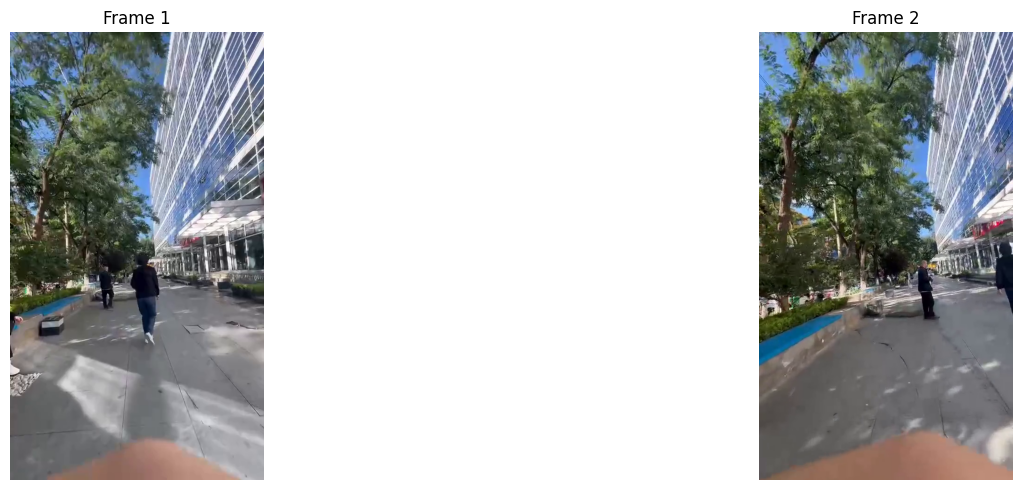

In [16]:
import matplotlib.pyplot as plt

# Pick a sample from the training set
sample = train_dataset[5]
frames = downsample_video(sample['video']['path'])
images = [img for img, _ in frames]

print(f"Label: {sample['alter']}")
print(f"Frames extracted: {len(images)}")

plt.figure(figsize=(20, 5))
for i, img in enumerate(images):
    plt.subplot(1, len(images), i + 1)
    plt.imshow(img)
    plt.title(f"Frame {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()


## Load Model

In [98]:
# model = Gemma3nForConditionalGeneration.from_pretrained(
#     "google/gemma-3n-E2B-it",
#     torch_dtype=torch.bfloat16,
# )
# processor = AutoProcessor.from_pretrained(
#     "google/gemma-3n-E2B-it",
# )
# processor.tokenizer.padding_side = "right"

# Reload clean base model
model = Gemma3nForConditionalGeneration.from_pretrained(
    "google/gemma-3n-E2B-it",
    torch_dtype=torch.bfloat16,
)
processor = AutoProcessor.from_pretrained("google/gemma-3n-E2B-it")
processor.tokenizer.padding_side = "right"

model.gradient_checkpointing_enable()
model.config.use_cache = False

print("✅ Fresh base model loaded!")


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1556 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



✅ Fresh base model loaded!


In [99]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"Number of GPUs: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"\nGPU {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory allocated: {torch.cuda.memory_allocated(i) / 1024**3:.2f} GB")
        print(f"  Memory reserved:  {torch.cuda.memory_reserved(i) / 1024**3:.2f} GB")


PyTorch version: 2.4.1+cu124
CUDA available: True
CUDA version: 12.4
Number of GPUs: 1

GPU 0: NVIDIA A40
  Memory allocated: 21.27 GB
  Memory reserved:  39.87 GB


## Data Collator

In [100]:
def collate_fn(examples):
    example = examples[0]

    video_path = example["video"]["path"]
    frames = downsample_video(video_path)

    text = "Given the visual input from the user’s forward perspective, generate exactly one short sentence to guide a visually impaired user by identifying critical obstacles or landmarks, describing their locations using clock directions relative to the user (12 o’clock is straight ahead), including relevant details such as size, material, or distance, and giving one clear action, while prioritizing immediate safety and avoiding any extra explanation."

    message = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": text}
            ],
        },
    ]

    for frame in frames:
        image, timestamp = frame
        message[0]["content"].append({"type": "text", "text": f"Frame at {timestamp}s:"})
        message[0]["content"].append({"type": "image", "image": image})

    message.append({
        "role": "assistant",
        "content": [{"type": "text", "text": example["alter"]}]
    })

    inputs = processor.apply_chat_template(
        message,
        add_generation_prompt=False,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        padding=True,
    ).to(model.device)

    labels = inputs["input_ids"].clone()
    special_token_ids = processor.tokenizer.all_special_ids
    special_token_ids_tensor = torch.tensor(special_token_ids, device=labels.device)
    mask = torch.isin(labels, special_token_ids_tensor)
    labels[mask] = -100
    inputs["labels"] = labels

    return inputs


## LoRA Configuration

In [101]:
from peft import LoraConfig

peft_config = LoraConfig(
    task_type="CAUSAL_LM",
    r=32,
    target_modules="all-linear",
    lora_alpha=64,
    lora_dropout=0.05,
    bias="none",
    use_rslora=False,
    use_dora=False,
    modules_to_save=None
)


In [102]:
model.gradient_checkpointing_enable()
model.config.use_cache = False


## Training

In [103]:
import shutil
shutil.rmtree("./gemma-3n-blind-assist", ignore_errors=True)
print("✅ Cleared old checkpoints")

✅ Cleared old checkpoints


In [104]:
training_args = SFTConfig(
    output_dir="./gemma-3n-blind-assist",
    eval_strategy='steps',
    eval_steps=250,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False}, 
    learning_rate=2e-04,
    num_train_epochs=3.0,
    warmup_steps=0.03,
    weight_decay=0.01,
    logging_steps=10,
    save_steps=250,
    save_total_limit=2,
    bf16=True,
    report_to=["wandb"],  # Log to both WandB and TensorBoard
    dataset_kwargs={'skip_prepare_dataset': True},
    remove_unused_columns=False,
    dataloader_pin_memory=False,
    push_to_hub=False, 
    hub_model_id=None, 
)


In [105]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    train_dataset=train_dataset,
    eval_dataset=test_dataset if training_args.eval_strategy != "no" else None,
    processing_class=processor.tokenizer,
    peft_config=peft_config,
)


In [106]:
print(f"Model device: {model.device}")
print(f"Model is on CUDA: {next(model.parameters()).is_cuda}")


Model device: cuda:0
Model is on CUDA: True


In [60]:
import importlib
from pathlib import Path

# Find TRL package location
import trl
trl_path = Path(trl.__file__).parent

template_path = trl_path / "templates" / "lm_model_card.md"
print(f"Template found at: {template_path}")

# Re-save with utf-8 encoding
content = template_path.read_text(encoding="utf-8")
template_path.write_text(content, encoding="utf-8")
print("✅ TRL template file fixed!")

Template found at: /usr/local/lib/python3.11/dist-packages/trl/templates/lm_model_card.md
✅ TRL template file fixed!


In [107]:
from trl.trainer import base_trainer
from trl.trainer import sft_trainer

# Override create_model_card to do nothing
def _skip_model_card(self, *args, **kwargs):
    pass  # do nothing instead of trying to read the template

base_trainer.BaseTrainer.create_model_card = _skip_model_card
print("✅ Model card generation disabled!")

✅ Model card generation disabled!


In [108]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.
/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Step,Training Loss,Validation Loss
250,0.932020,0.213372
500,0.688672,0.178265
750,0.582931,0.173901
1000,0.641860,0.164311
1250,0.615482,0.158477
1500,0.623621,0.157212
1750,0.530823,0.151235
2000,0.610623,0.147692
2250,0.528136,0.145470
2500,0.520964,0.145188


/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]
/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x60fb66c0] moov atom not found
/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr

In [ ]:
wandb.finish()


eval/entropy,▅▄█▄▆▇▇▇▂▄▃▄▂▃▃▂▂▁▂▁▁▁
eval/loss,█▅▄▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
eval/mean_token_accuracy,▁▃▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇████
eval/num_tokens,▁▁▂▂▂▃▃▃▄▄▄▅▅▅▆▆▆▇▇▇██
eval/runtime,▂▃█▅▄▄▄▂▂▂▁▁▁▁▁▂▃▃▁▁▁▁
eval/samples_per_second,▇▆▁▄▅▅▅▇▇▇█████▇▆▆████
eval/steps_per_second,▇▆▁▄▅▅▅▇▇▇█████▇▆▆████
train/entropy,▃▂▂▄▄▆█▆▆▅▆▅█▇█▆█▆▆▆▂▃▃▅▆▅▃▃▄▄▂▁▂▂▂▁▁▁▁▁
train/epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇█████
train/global_step,▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇███
+5,...


In [ ]:
# Memory stats after training
gpu_stats = torch.cuda.get_device_properties(0)
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"Peak reserved memory = {used_memory} GB ({round(used_memory/max_memory*100, 2)}%)")
print(f"Training time: {round(trainer_stats.metrics['train_runtime']/60, 2)} minutes")


GPU = NVIDIA A40. Max memory = 44.432 GB.
Peak reserved memory = 43.812 GB (98.6%)
Training time: 958.68 minutes


## Test the Model

In [ ]:
import torch

model = trainer.model
model.eval()

# Use a sample from test set
video_file = train_dataset[1000]['video']['path']
frames = downsample_video(video_file)

prompt_text = "Given the visual input from the user’s forward perspective, generate exactly one short sentence to guide a visually impaired user by identifying critical obstacles or landmarks, describing their locations using clock directions relative to the user (12 o’clock is straight ahead), including relevant details such as size, material, or distance, and giving one clear action, while prioritizing immediate safety and avoiding any extra explanation."

message = [
    {
        "role": "user",
        "content": [{"type": "text", "text": prompt_text}],
    },
]

for image, timestamp in frames:
    message[0]["content"].append({"type": "text", "text": f"Frame {timestamp}s:"})
    message[0]["content"].append({"type": "image", "image": image})

inputs = processor.apply_chat_template(
    message,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
).to(model.device).to(model.dtype)

input_len = inputs["input_ids"].shape[-1]

with torch.inference_mode():
    generation = model.generate(**inputs, max_new_tokens=128, do_sample=False)
    generation = generation[0][input_len:]

decoded = processor.decode(generation, skip_special_tokens=True)
print("\n--- Model Navigation Advice ---")
print(decoded)



--- Model Navigation Advice ---
at 11 o'clock direction, there are pedestrians passing by, pay attention to avoid.


## Upload to HuggingFace Hub

In [ ]:
# Merge LoRA adapters into the base model first
merged_model = trainer.model.merge_and_unload()

# Push full merged model to HuggingFace Hub
HF_REPO = "blind-assist/google-gemma-3n-2b-e3"  # change to your personal namespace

merged_model.push_to_hub(HF_REPO, token="")
processor.push_to_hub(HF_REPO, token="")

print(f"✅ Full model uploaded to: https://huggingface.co/{HF_REPO}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✅ Full model uploaded to: https://huggingface.co/blind-assist/google-gemma-3n-2b-e3
